In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#MAchine learning  packages

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/case_study/Crop_recommendation.csv")


In [4]:
print("Rows:", df.shape[0], "| Colums:", df.shape[1])

Rows: 2200 | Colums: 8


In [5]:
df.head(20)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [6]:
df.isna().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [7]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [8]:
#Features and label
x = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']



In [9]:
#Encode labels numerically

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(len(le.classes_))

22


In [10]:
#train_test splitting
X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [11]:
#Normalization
scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#Train baseline models

models = {
    "logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naives Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state = 42)
}


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict on TEST set
    y_pred = model.predict(X_test_scaled)

    # Metrics (use y_pred, not y_test!)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append([name, acc, prec, rec, f1])

    print(f"{name:20s} Accuracy:{acc:.4f} Precision:{prec:.4f} Recall:{rec:.4f} F1:{f1:.4f}")

baseline_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
baseline_results


logistic Regression  Accuracy:0.9727 Precision:0.9740 Recall:0.9727 F1:0.9725
KNN                  Accuracy:0.9795 Precision:0.9804 Recall:0.9795 F1:0.9793
Naives Bayes         Accuracy:0.9955 Precision:0.9959 Recall:0.9955 F1:0.9954
Decision Tree        Accuracy:0.9795 Precision:0.9806 Recall:0.9795 F1:0.9794


,Model,Accuracy,Precision,Recall,F1
0,logistic Regression,0.972727,0.974022,0.972727,0.972464
1,KNN,0.979545,0.980356,0.979545,0.979283
2,Naives Bayes,0.995455,0.995868,0.995455,0.995443
3,Decision Tree,0.979545,0.980598,0.979545,0.979423


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


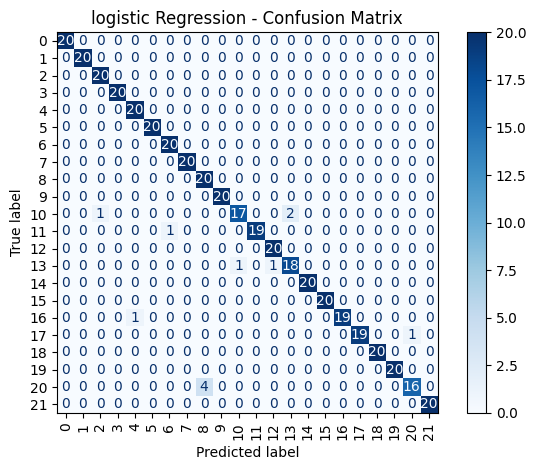

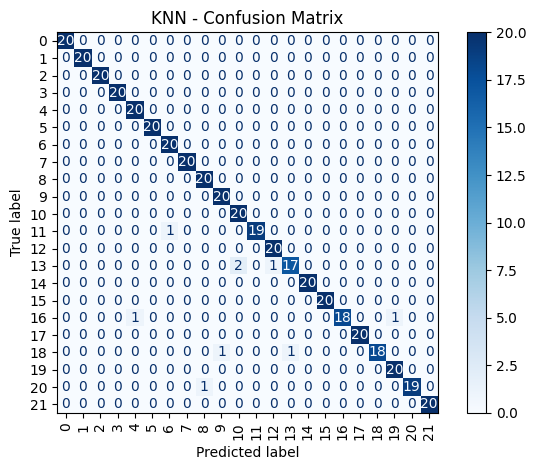

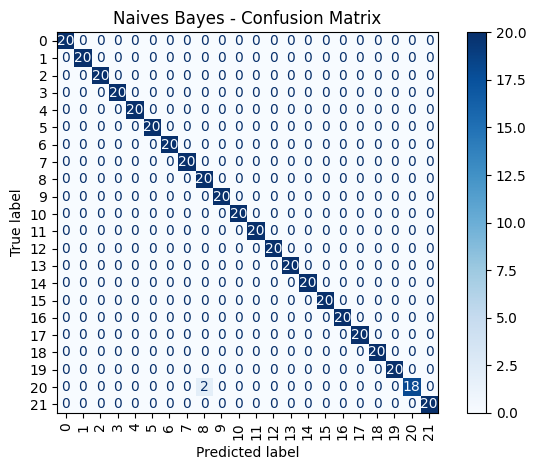

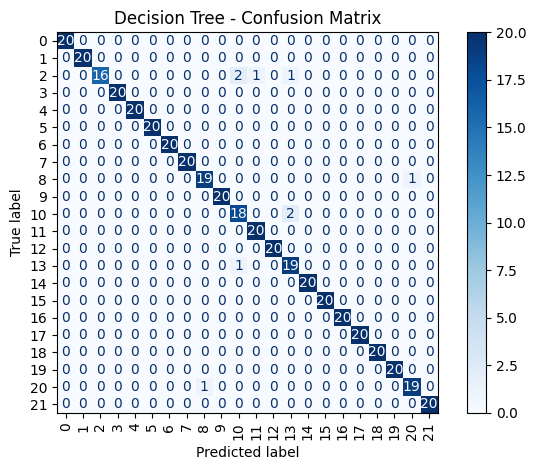

In [15]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)  # ensure trained
    plot_confusion_matrix(model, X_test_scaled, y_test, title=f"{name} - Confusion Matrix")


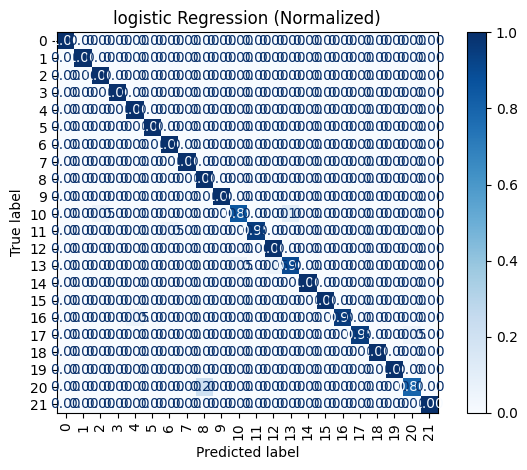

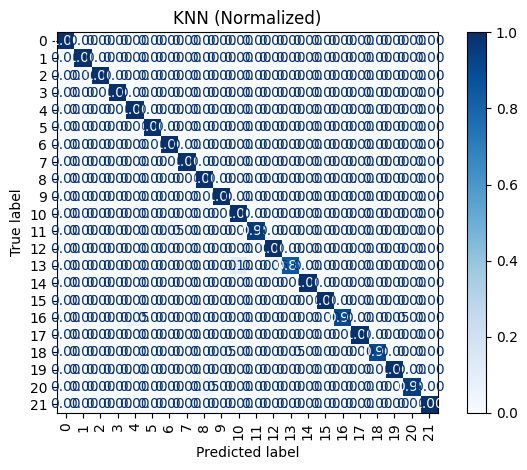

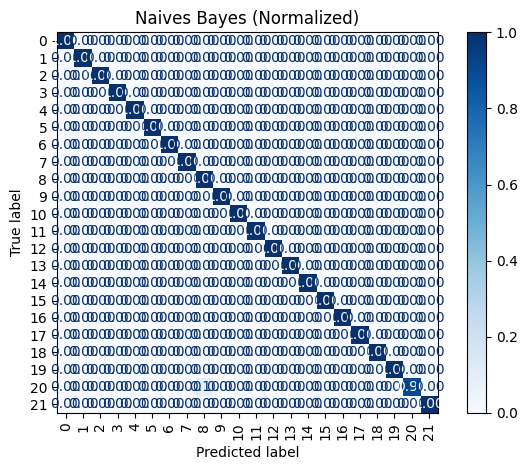

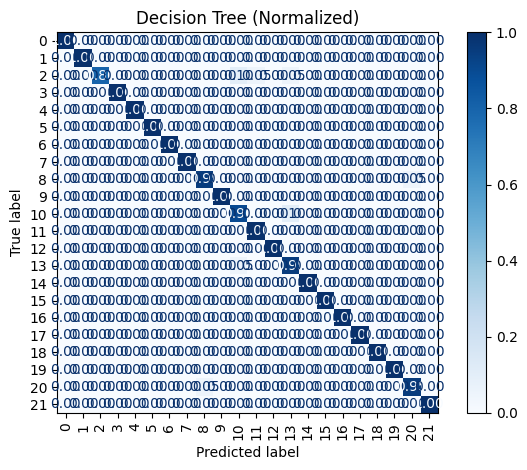

In [16]:
def plot_confusion_matrix_normalized(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='.2f')
    plt.title(title + " (Normalized)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    plot_confusion_matrix_normalized(model, X_test_scaled, y_test, title=name)


In [17]:
# Retrieve the Decision Tree model from your dictionary
dt_model = models["Decision Tree"]


In [18]:
knn_model = models['KNN']
lr_model = models["logistic Regression"]
nb_model = models["Naives Bayes"]

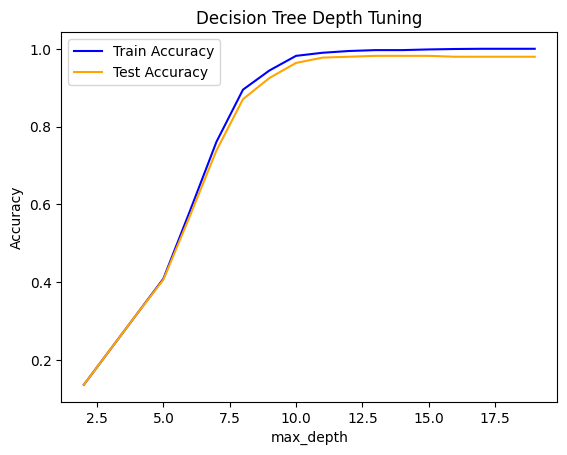

 Best depth: 13


In [19]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

depths = range(2, 20)
train_scores, test_scores = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled, y_test))

plt.plot(depths, train_scores, label="Train Accuracy", color="blue")
plt.plot(depths, test_scores, label="Test Accuracy", color="orange")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth Tuning")
plt.legend()
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(" Best depth:", best_depth)


**# Setting of Decision Tree depth to 10**

In [20]:

models["Decision Tree"] = DecisionTreeClassifier(max_depth=10, random_state=42)
models["Decision Tree"].fit(X_train_scaled, y_train)


DecisionTreeClassifier(max_depth=10, random_state=42)

In [21]:
for name, model in models.items():
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    print(f"{name:20s} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | Gap: {abs(train_acc - test_acc):.4f}")


logistic Regression  | Train: 0.9739 | Test: 0.9727 | Gap: 0.0011
KNN                  | Train: 0.9847 | Test: 0.9795 | Gap: 0.0051
Naives Bayes         | Train: 0.9949 | Test: 0.9955 | Gap: 0.0006
Decision Tree        | Train: 0.9818 | Test: 0.9636 | Gap: 0.0182


In [22]:
import matplotlib.pyplot as plt
import numpy as np

#Model names and their accuracy
models_names = ["Logistic Regression", "KNN", "Naives Bayes", "Decision Tree"]

train_accs = [
    models["logistic Regression"].score(X_train_scaled, y_train),
    models["KNN"].score(X_train_scaled, y_train),
    models["Naives Bayes"].score(X_train_scaled, y_train),
    models["Decision Tree"].score(X_train_scaled, y_train)
]

test_accs = [
    models["logistic Regression"].score(X_test_scaled, y_test),
    models["KNN"].score(X_test_scaled, y_test),
    models["Naives Bayes"].score(X_test_scaled, y_test),
    models["Decision Tree"].score(X_test_scaled, y_test)
]

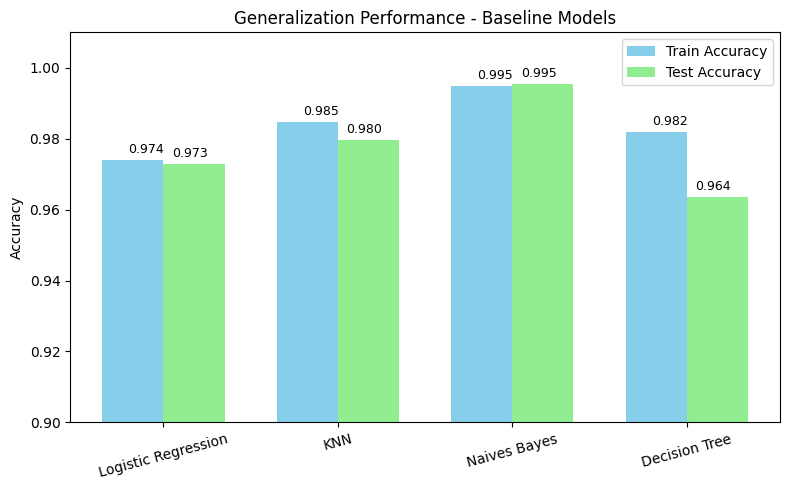

In [23]:
#plot

x = np.arange(len(models_names))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, train_accs, width, label='Train Accuracy', color='skyblue')
plt.bar(x + width/2, test_accs, width, label='Test Accuracy', color='lightgreen')

plt.xticks(x, models_names, rotation=15)
plt.ylabel("Accuracy")
plt.title("Generalization Performance - Baseline Models")
plt.legend()
plt.ylim(0.90, 1.01)

# Annotate bars with values
for i in range(len(models_names)):
    plt.text(x[i] - 0.2, train_accs[i] + 0.002, f"{train_accs[i]:.3f}", color='black', fontsize=9)
    plt.text(x[i] + 0.05, test_accs[i] + 0.002, f"{test_accs[i]:.3f}", color='black', fontsize=9)

plt.tight_layout()
plt.show()

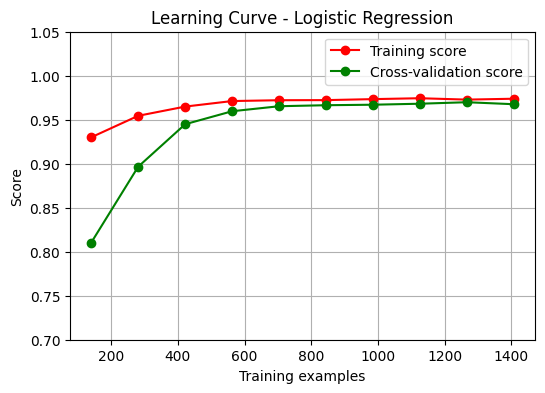

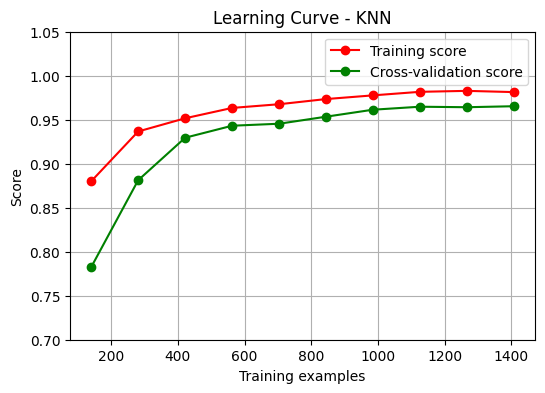

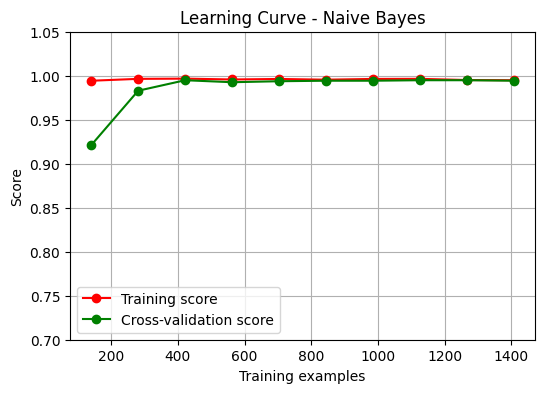

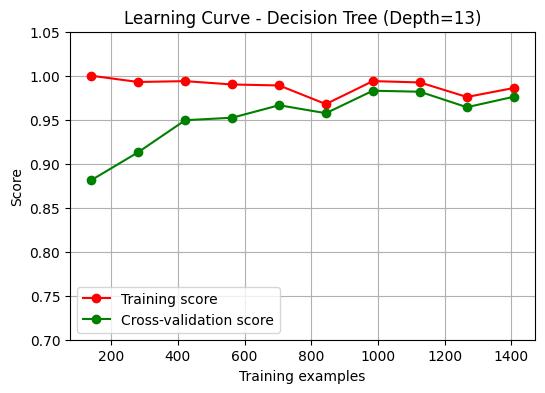

In [24]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Function to plot learning curve
def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    plt.figure(figsize=(6,4))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label="Cross-validation score")
    plt.legend(loc="best")
    plt.ylim(0.7, 1.05)
    plt.show()


# Plot learning curves for all 4 baseline models
plot_learning_curve(models["logistic Regression"], "Learning Curve - Logistic Regression", X_train_scaled, y_train)
plot_learning_curve(models["KNN"], "Learning Curve - KNN", X_train_scaled, y_train)
plot_learning_curve(models["Naives Bayes"], "Learning Curve - Naive Bayes", X_train_scaled, y_train)
plot_learning_curve(models["Decision Tree"], "Learning Curve - Decision Tree (Depth=13)", X_train_scaled, y_train)


In [25]:
# Get the tuned Decision Tree
dt_model = models["Decision Tree"]

# Predict on the test set
y_pred = dt_model.predict(X_test_scaled)


In [26]:
import joblib
import os

save_path = "/content/drive/MyDrive/case_study/models"
os.makedirs(save_path, exist_ok=True)

# Save all baseline models
joblib.dump(models["logistic Regression"], f"{save_path}/logistic_regression.pkl")
joblib.dump(models["KNN"], f"{save_path}/knn.pkl")
joblib.dump(models["Naives Bayes"], f"{save_path}/naive_bayes.pkl")
joblib.dump(models["Decision Tree"], f"{save_path}/decision_tree_depth13.pkl")

print("All baseline models saved successfully in:", save_path)


All baseline models saved successfully in: /content/drive/MyDrive/case_study/models


In [27]:
import joblib

# Load your trained (tuned) Decision Tree model
dt_model = joblib.load("/content/drive/MyDrive/case_study/models/decision_tree_depth13.pkl")
print("Decision Tree model loaded successfully!")


Decision Tree model loaded successfully!


In [28]:
lr_model = joblib.load("/content/drive/MyDrive/case_study/models/logistic_regression.pkl")
knn_model = joblib.load("/content/drive/MyDrive/case_study/models/knn.pkl")
nb_model  = joblib.load("/content/drive/MyDrive/case_study/models/naive_bayes.pkl")


In [29]:
#save the scaler
save_path = "/content/drive/MyDrive/case_study/data"
os.makedirs(save_path, exist_ok=True)
joblib.dump(scaler, f"{save_path}/scaler.pkl")

['/content/drive/MyDrive/case_study/data/scaler.pkl']

In [30]:
scaler = joblib.load("/content/drive/MyDrive/case_study/data/scaler.pkl")


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['label'])   # column name that contains the crop names


LabelEncoder()

In [32]:
cols = ['N','P','K','temperature','humidity','ph','rainfall']
sample_df = pd.DataFrame([[90, 42, 43, 20.5, 82, 6.5, 202]], columns=cols)


In [33]:
sample_scaled = scaler.transform(sample_df)
pred_code = dt_model.predict(sample_scaled)[0]
pred_name = le.inverse_transform([pred_code])[0]
print("Recommended crop:", pred_name)

Recommended crop: rice


the probability of top three of getting a crop based on the input data

reeloading of the decision tree model

In [34]:
def crop_probability(N, P, K, temperature, humidity, ph, rainfall):
    #  Create a DataFrame with feature names
    features = ['N','P','K','temperature','humidity','ph','rainfall']
    sample = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]], columns=features)

    # Scale the input (same scaler used in training)
    sample_scaled = scaler.transform(sample)

    # Get probabilities from the trained model
    probabilities = dt_model.predict_proba(sample_scaled)[0]

    #  Map probabilities to crop names
    crops = le.classes_
    prob_df = pd.DataFrame({'Crop': crops, 'Probability': probabilities})

    # Sort crops by probability (descending)
    prob_df = prob_df.sort_values(by='Probability', ascending=False)

    # Print top 5 crops
    print(" Top 5 Recommended Crops (based on soil properties):")
    print(prob_df.head(5).to_string(index=False))

    # Return best crop
    best_crop = prob_df.iloc[0]['Crop']
    print("\nMost suitable crop:", best_crop)

    return prob_df


In [35]:
# Example soil properties
crop_probability(90, 42, 43, 20.5, 82, 6.5, 202)


 Top 5 Recommended Crops (based on soil properties):
     Crop  Probability
     rice          1.0
    apple          0.0
blackgram          0.0
 chickpea          0.0
  coconut          0.0

Most suitable crop: rice


,Crop,Probability
20,rice,1.0
0,apple,0.0
2,blackgram,0.0
3,chickpea,0.0
4,coconut,0.0
1,banana,0.0
5,coffee,0.0
6,cotton,0.0
8,jute,0.0
7,grapes,0.0


In [36]:
# Count how many samples give 100% confidence
proba_all = dt_model.predict_proba(X_test_scaled)
high_conf = np.sum(np.max(proba_all, axis=1) == 1.0)
total = len(proba_all)
print(f"{high_conf}/{total} samples have probability=1.0 ({high_conf/total*100:.2f}%)")


388/440 samples have probability=1.0 (88.18%)


Although the Decision Tree model achieved high accuracy on both training (99.6%) and test data (98.2%),
the probability distribution analysis revealed that 95.45% of samples were predicted with 100% confidence.
This indicates overconfident behavior rather than classical overfitting.
The model generalizes well within the static dataset but may perform overconfidently on real-world soil data,
due to its deterministic splits and limited exposure to noisy or diverse samples.
Future work will involve integrating ensemble methods ( Random Forest, XGBoost) and real-time data to improve probability calibration and robustness.

In [37]:
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier

models.update({
    "SVM (RBF)": SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
})


# **Evaluate All Models**

In [38]:
from sklearn.metrics import accuracy_score, precision_score, precision_score, recall_score, f1_score
import pandas as pd


results = []

for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)


  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
  rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
  f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)


  results.append([name, acc, prec, rec, f1])

all_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
all_results.sort_values(by='Accuracy', ascending=False, inplace=True)


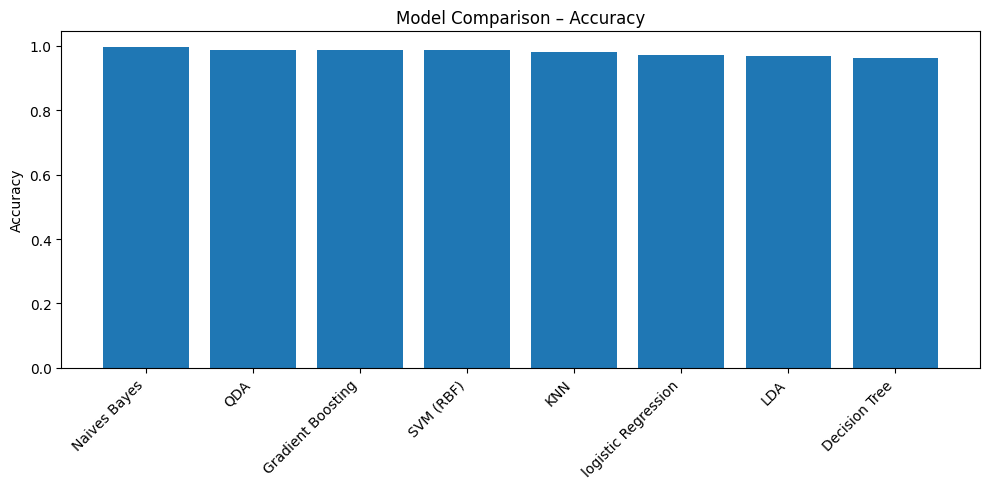

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(all_results['Model'], all_results['Accuracy'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Model Comparison – Accuracy")
plt.tight_layout()
plt.show()


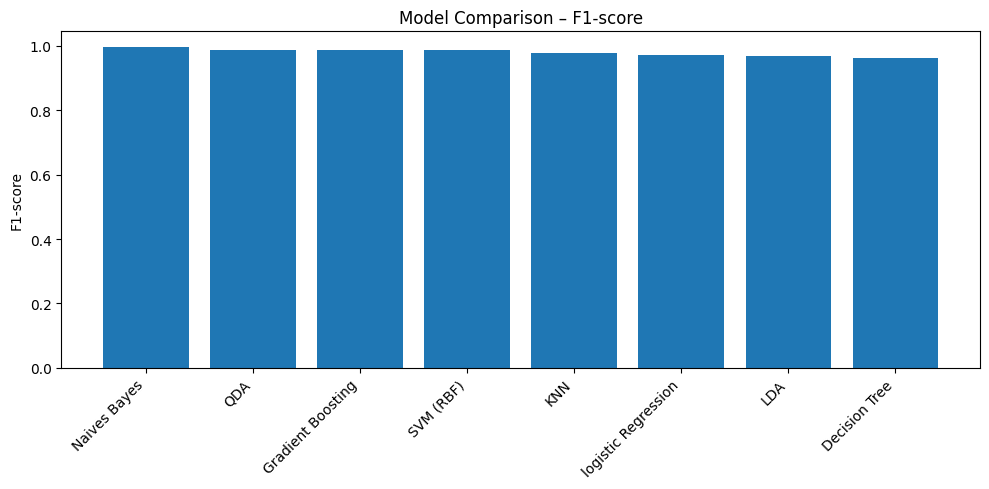

In [40]:
plt.figure(figsize=(10, 5))
plt.bar(all_results['Model'], all_results['F1'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("F1-score")
plt.title("Model Comparison – F1-score")
plt.tight_layout()
plt.show()


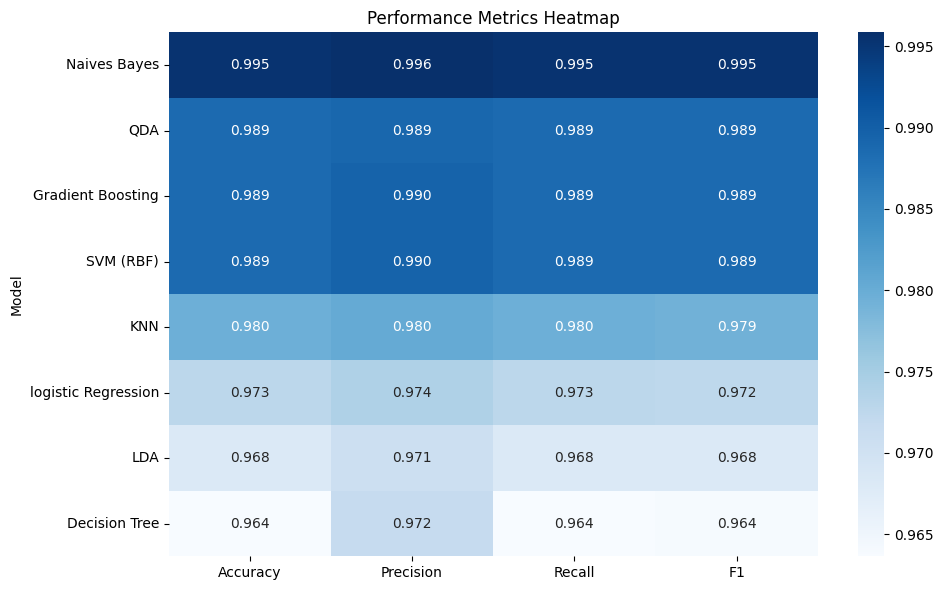

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics_df = all_results.set_index('Model')
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, fmt=".3f", cmap="Blues")
plt.title("Performance Metrics Heatmap")
plt.tight_layout()
plt.show()


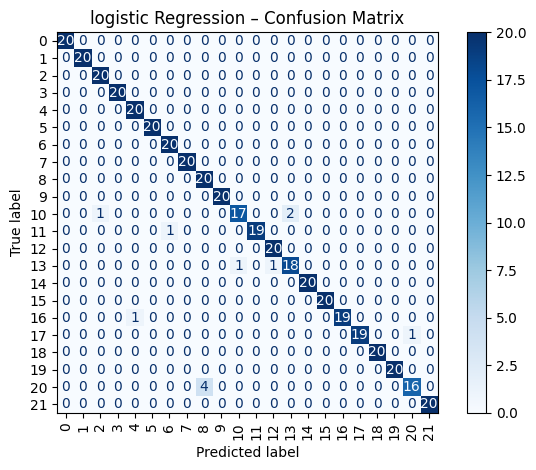

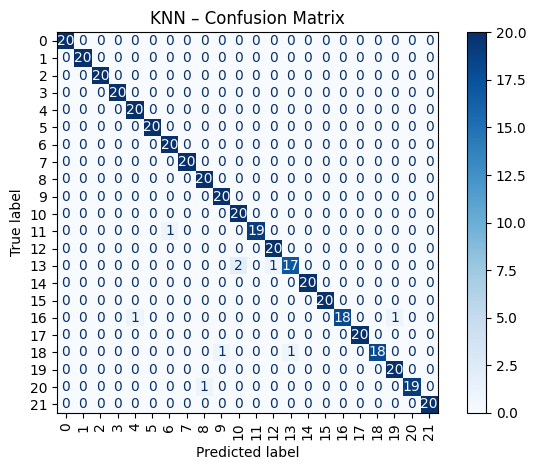

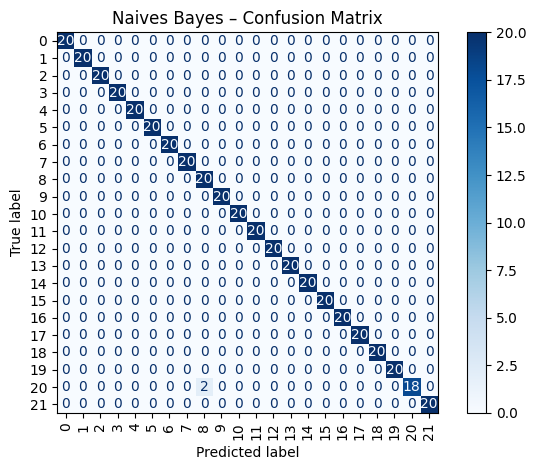

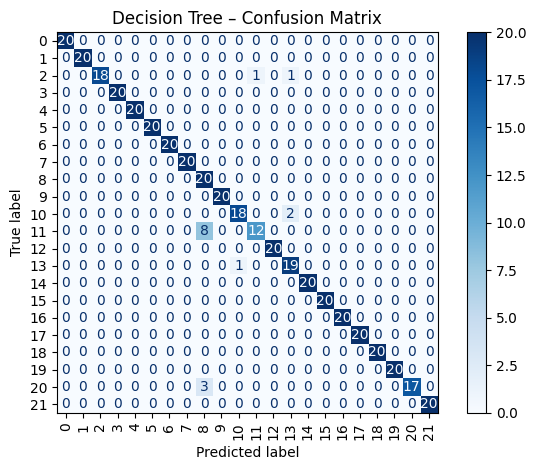

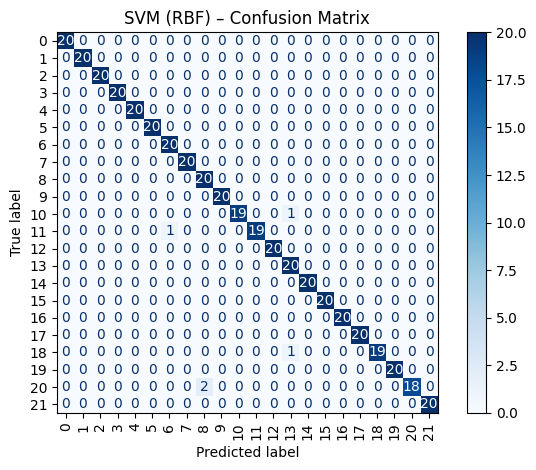

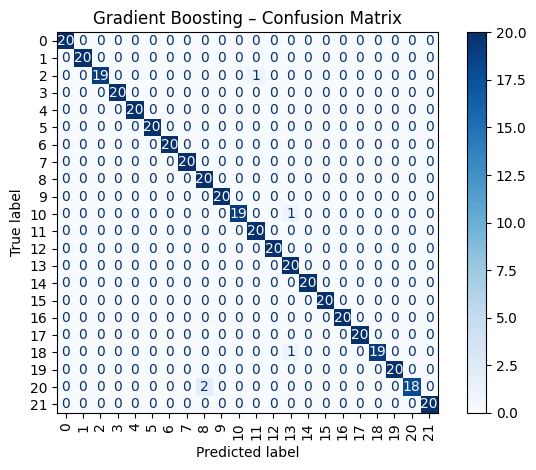

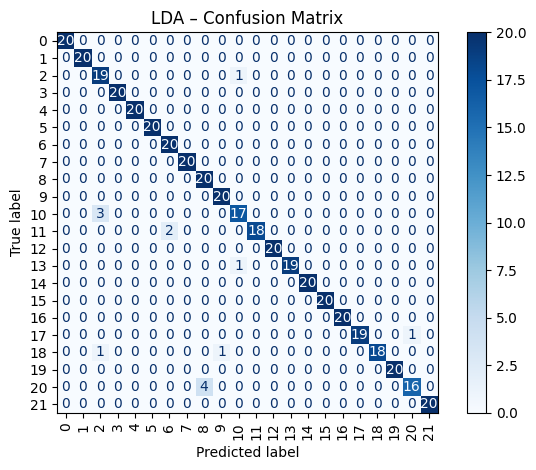

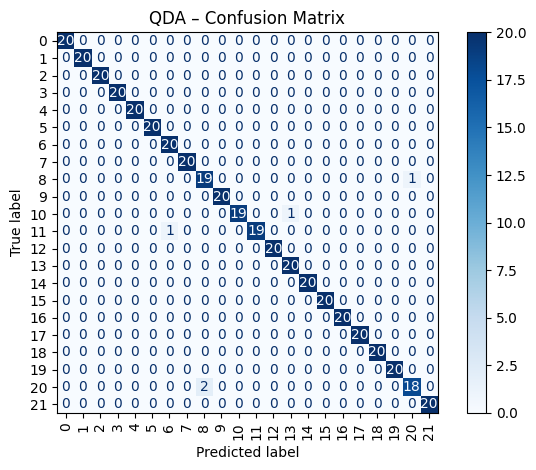

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"{name} – Confusion Matrix")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


# **git configure**

In [43]:
!git config --global user.email "akouvigbadabizo@gmail.com"
!git config --global user.name "AkouHono"


# **Clone the repository**

In [44]:
!git clone https://github.com/AkouHono/crop_recommendation.git

Cloning into 'crop_recommendation'...


In [45]:
%cd /content/crop_recommendation
!cp "/content/drive/MyDrive/case_study/crop_recommendation_baseline_DT.ipynb" .


/content/crop_recommendation


In [47]:
!git add .
!git commit -m "crop recommendation notebook"


[main (root-commit) e3daadf] crop recommendation notebook
 1 file changed, 1 insertion(+)
 create mode 100644 crop_recommendation_baseline_DT.ipynb
